## Import Dependecies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import fetch_california_housing

# Data splitting and Hyperparameter tuning
from sklearn.model_selection import train_test_split, cross_val_score, KFold

# Preprocessing
from sklearn.preprocessing import StandardScaler


# Pipeline
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression

# Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
# Configurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
%matplotlib Inline

In [ ]:
# Load the dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

## Data Inspection and Understanding

In [ ]:
print("Data Shape: ", df.shape)
print("\nData Information:")
print(df.info())
print("\nSummary Statistics:\n", df.describe())
print("\nfirst 5 rows:\n", df.head())


Data Shape:  (20640, 9)

Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Summary Statistics:
          MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count 20640.000 20640.000 20640.000  20640.000   20640.000 20640.000   
mean      3.871    28.639     5.429      1.097    1425.477     3.071   
std       1.900    12.586     2.474      0.474    1132.462    10.386   
min       0.500     1.000     0.

## Exploratory Data Analysis

In [ ]:
# Check for missing values
print("\nmissing values:")
print(df.isna().sum())

# Check for duplicates
print("\nduplicates:")
print(df.duplicated().sum())



missing values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

duplicates:
0


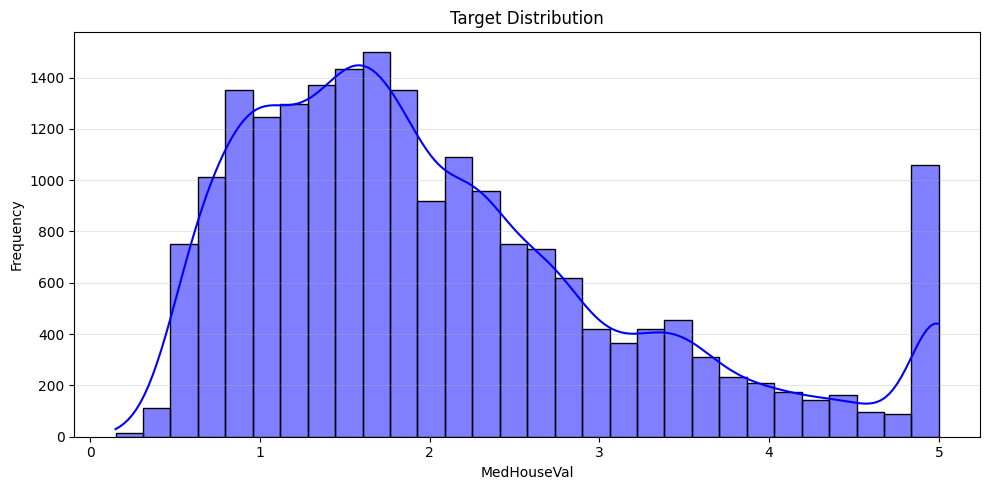

In [ ]:
# Target Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df["MedHouseVal"], bins=30, kde=True, color="blue")
plt.title("Target Distribution")
plt.xlabel("MedHouseVal")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

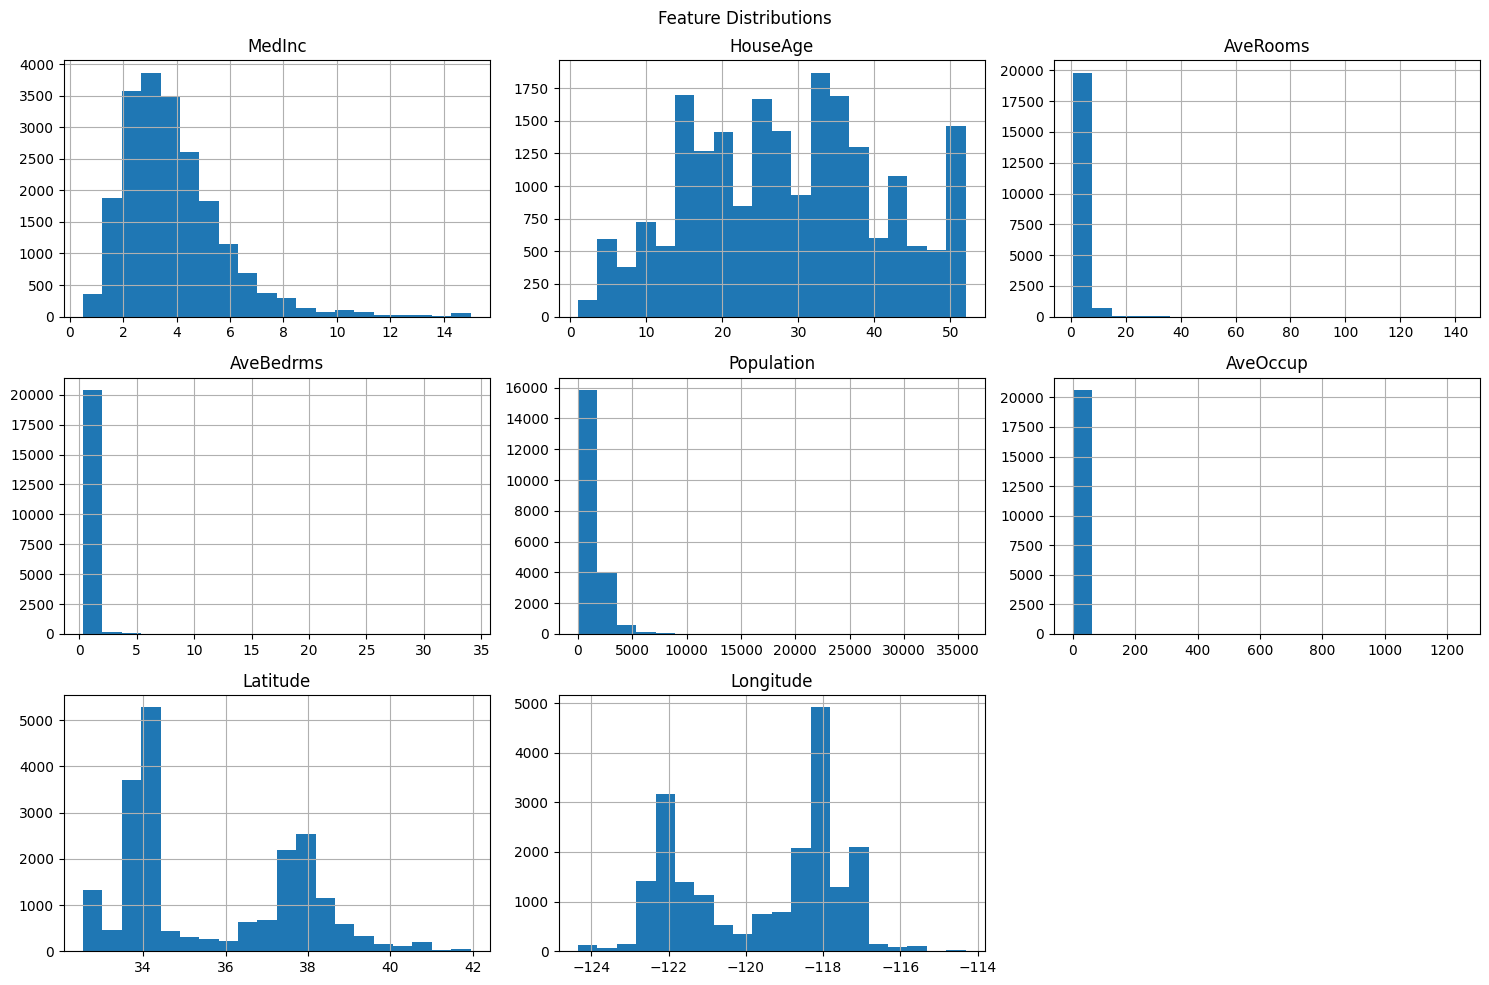

In [ ]:
# Feature Distributions
df.drop("MedHouseVal", axis=1).hist(figsize=(15, 10), bins=20)
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

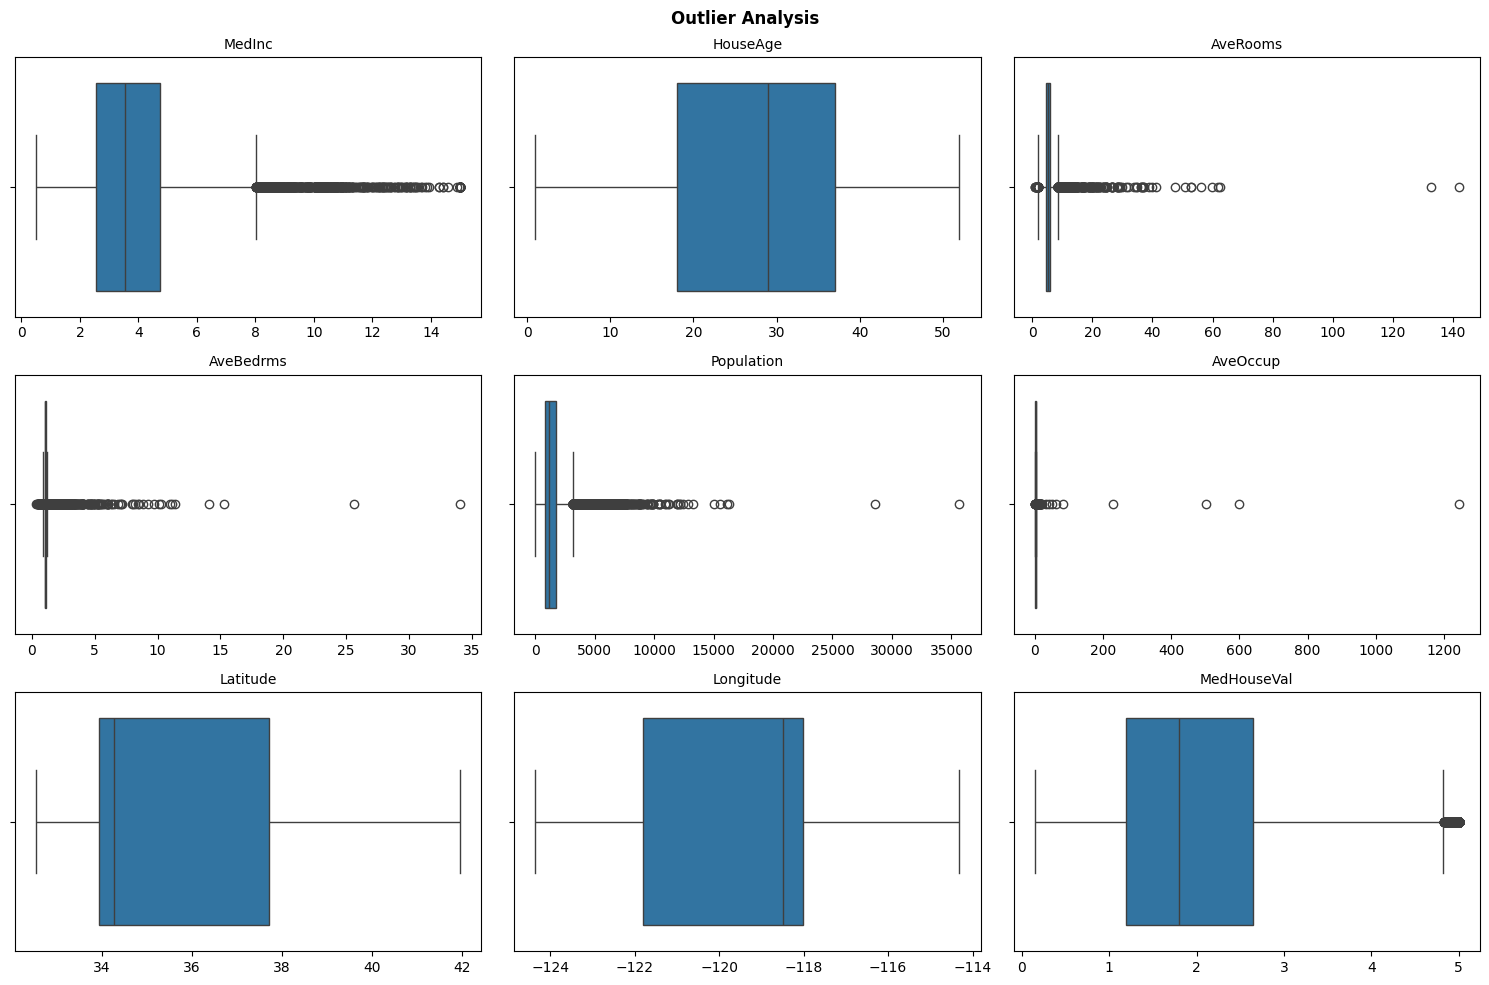

In [ ]:
# Outlier Analysis
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(df):
    sns.boxplot(data=df, x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
plt.suptitle("Outlier Analysis", fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
#  Feature Correlation
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000,-0.119,0.327,-0.062,0.005,0.019,-0.080,-0.015,0.688
HouseAge,-0.119,1.000,-0.153,-0.078,-0.296,0.013,0.011,-0.108,0.106
AveRooms,0.327,-0.153,1.000,0.848,-0.072,-0.005,0.106,-0.028,0.152
AveBedrms,-0.062,-0.078,0.848,1.000,-0.066,-0.006,0.070,0.013,-0.047
Population,0.005,-0.296,-0.072,-0.066,1.000,0.070,-0.109,0.100,-0.025
AveOccup,0.019,0.013,-0.005,-0.006,0.070,1.000,0.002,0.002,-0.024
Latitude,-0.080,0.011,0.106,0.070,-0.109,0.002,1.000,-0.925,-0.144
Longitude,-0.015,-0.108,-0.028,0.013,0.100,0.002,-0.925,1.000,-0.046
MedHouseVal,0.688,0.106,0.152,-0.047,-0.025,-0.024,-0.144,-0.046,1.000


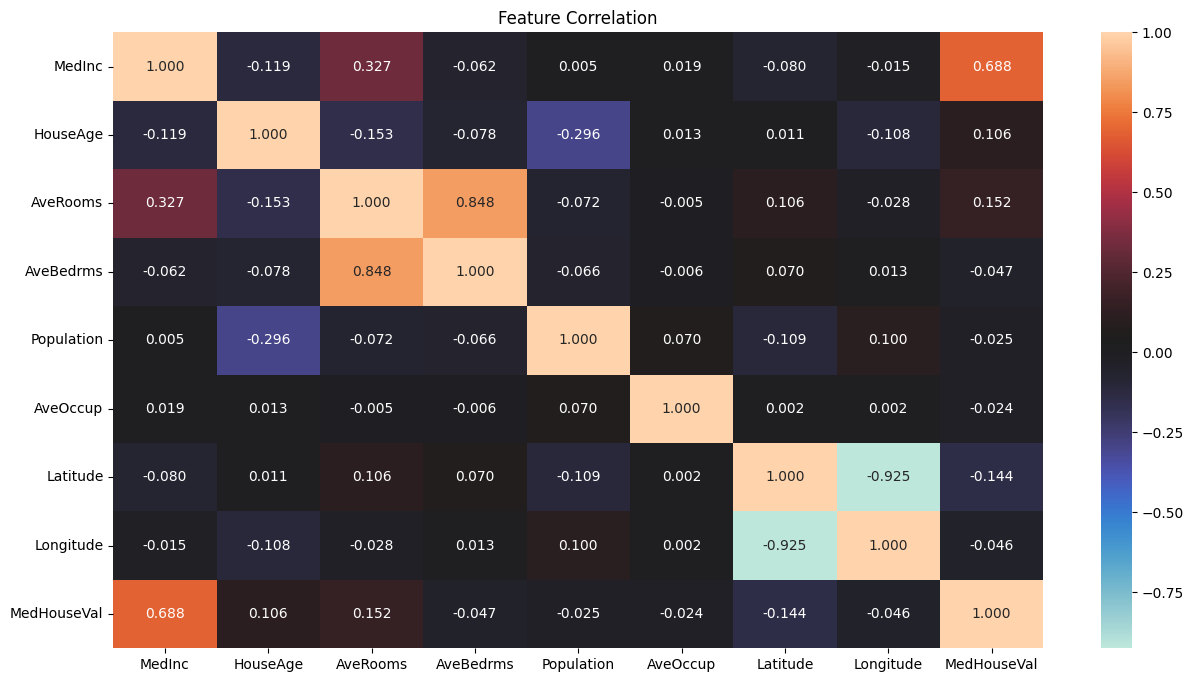

In [ ]:
# Feature Correlation plot
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(), annot=True, fmt=".3f", cmap="icefire")
plt.title("Feature Correlation")
plt.show()

In [ ]:
df.drop("MedHouseVal", axis=1).corrwith(df["MedHouseVal"]).sort_values(ascending=False)

,0
MedInc,0.688
AveRooms,0.152
HouseAge,0.106
AveOccup,-0.024
Population,-0.025
Longitude,-0.046
AveBedrms,-0.047
Latitude,-0.144


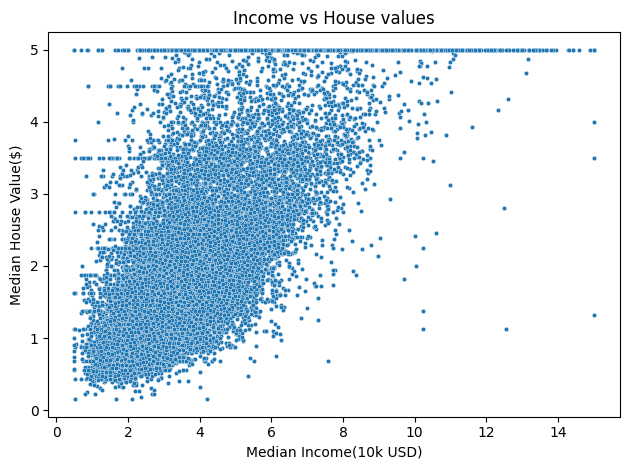

In [ ]:
# Strong Feature vs Target
sns.scatterplot(data = df, x = "MedInc", y = "MedHouseVal", s=10)
plt.title("Income vs House values")
plt.xlabel("Median Income(10k USD)")
plt.ylabel("Median House Value($)")
plt.tight_layout()
plt.show()

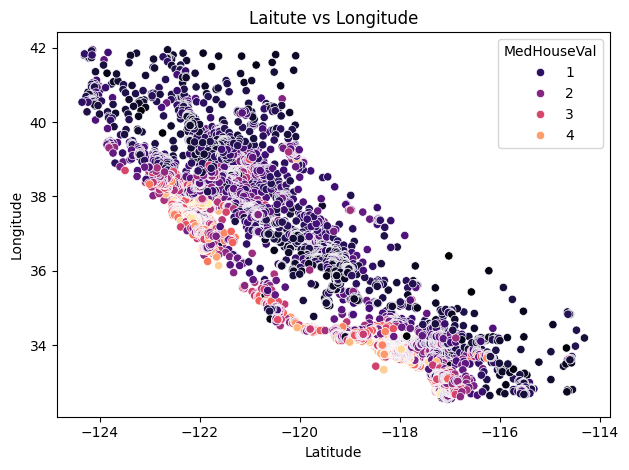

In [ ]:
# Location plot
colors = sns.color_palette("viridis", len(df))
sns.scatterplot(data = df, x = "Longitude", y = "Latitude", hue="MedHouseVal", palette="magma")
plt.title("Laitute vs Longitude")
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.tight_layout()
plt.show()

## Data Cleaning / Preprocessing

In [ ]:
df["MedHouseVal"].value_counts().sort_values(ascending=False).head()

,count
MedHouseVal,
5.000,965
1.375,122
1.625,117
1.125,103
1.875,93


In [ ]:
df = df[df["MedHouseVal"] < 5.0].reset_index(drop=True)
print(f"\nRemaining rows after dropping the capped target: {len(df)}" )


Remaining rows after dropping the capped target: 19648


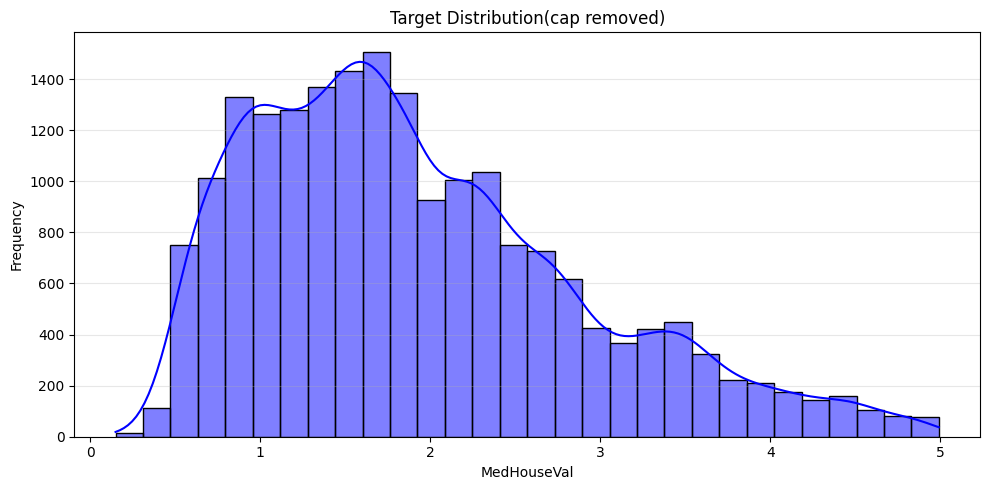

In [ ]:
# Target Distribution after dropping the capped
plt.figure(figsize=(10, 5))
sns.histplot(data = df, x= df["MedHouseVal"], bins=30, kde=True, color="blue")
plt.title("Target Distribution(cap removed)")
plt.xlabel("MedHouseVal")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
df["MedHouseVal"].value_counts().sort_values(ascending=False).head()

,count
MedHouseVal,
1.375,122
1.625,117
1.125,103
1.875,93
2.250,92


## Model Development and Training

In [ ]:
# Creating Features and Target variables
X = df.drop("MedHouseVal", axis = 1)
y= df["MedHouseVal"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (15718, 8)
Testing data shape: (3930, 8)


In [ ]:
# Model

model_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

In [ ]:
# Training
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

In [ ]:
# Prediction
y_pred = model_pipeline.predict(X_test)
print("\nPredicted values:")
print(y_pred)


Predicted values:
[2.77716494 2.64363229 2.77467155 ... 1.45517668 1.34625095 2.83096047]


In [ ]:
# Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n========= EVALUATION METRICS =========")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.2f}")


========= EVALUATION METRICS =========
MAE: 0.48
MSE: 0.41
RMSE: 0.64
R2: 0.57


In [ ]:
# Cross Validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model_pipeline, X_train, y_train, cv=kfold, scoring='neg_root_mean_squared_error')
cv_scores = -cv_scores

print("Fold scores:", cv_scores.round(4))
print(f"Mean RMSE: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Fold scores: [0.6166 0.6488 0.6424 0.6354 0.6255]
Mean RMSE: 0.6337 ± 0.0115


In [ ]:
# Actual vs Predicted values
comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})

print("\nActual vs Predicted values:")
print(comparison.head(20))


Actual vs Predicted values:
    Actual  Predicted
0    3.298      2.777
1    2.947      2.644
2    1.957      2.775
3    1.615      1.682
4    2.750      2.561
5    1.370      1.889
6    2.660      2.898
7    0.813      0.320
8    0.928      1.739
9    2.737      2.875
10   2.370      1.945
11   2.713      2.429
12   1.989      1.958
13   0.766      2.069
14   0.649      0.450
15   2.010      2.406
16   0.456      0.665
17   3.127      2.387
18   3.814      2.481
19   2.083      2.710


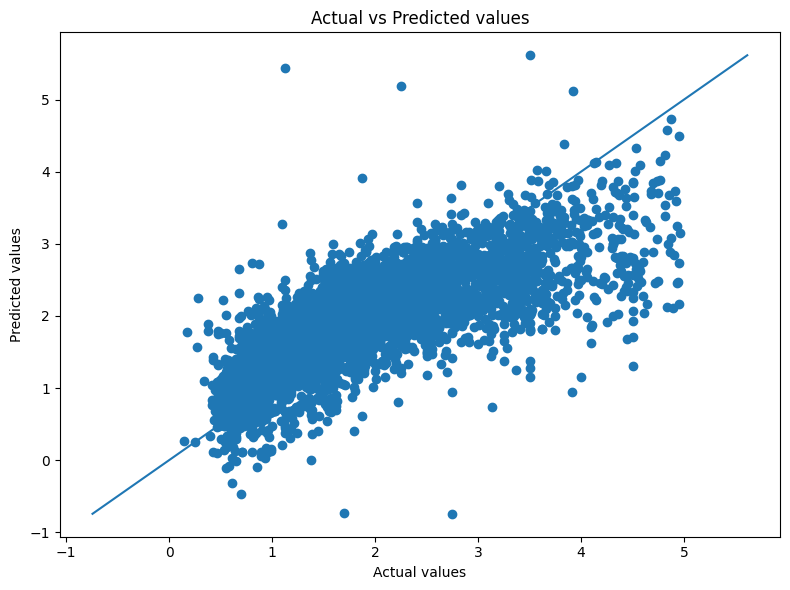

In [ ]:
# Actual vs Predicted plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test.values, y_pred)

# Perfect prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value])

plt.title("Actual vs Predicted values")
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.tight_layout()
plt.show()

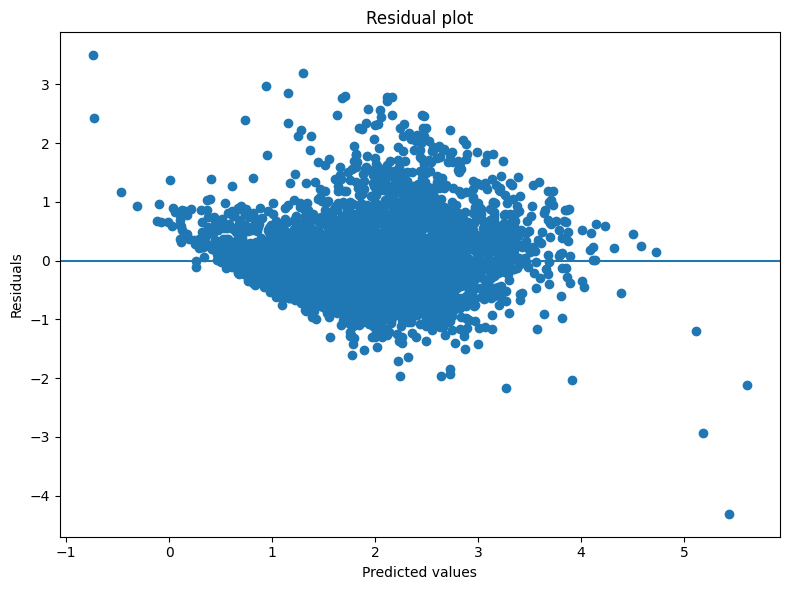

In [ ]:
# Residual Analysis
residuals = (y_test - y_pred)

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.title("Residual plot")
plt.xlabel("Predicted values")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

In [ ]:
# Model Interpretation (Feature Importance)
importances = (model_pipeline.named_steps['model'].coef_)
feature_importance = pd.DataFrame({'Features': X.columns, 'Importance': importances}).sort_values(by ='Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)


Feature Importance:
     Features  Importance
0      MedInc       0.673
3   AveBedrms       0.275
1    HouseAge       0.100
4  Population       0.006
5    AveOccup      -0.037
2    AveRooms      -0.246
7   Longitude      -0.786
6    Latitude      -0.809
